In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections import Counter

DATA_PATH = os.path.expanduser("~/Downloads/sleep-edf-database-expanded-1.0.0")
CASSETTE_PATH = os.path.join(DATA_PATH, "sleep-cassette")

FIGURES_PATH = os.path.expanduser("~/Desktop/sleeping-staging/eda/figures")
os.makedirs(FIGURES_PATH, exist_ok=True)

print(f"그래프 저장 경로: {FIGURES_PATH}")

그래프 저장 경로: /Users/sinyunju/Desktop/sleeping-staging/eda/figures


In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_PATH = os.path.expanduser("~/Downloads/sleep-edf-database-expanded-1.0.0")
CASSETTE_PATH = os.path.join(DATA_PATH, "sleep-cassette")

psg_files = sorted([f for f in os.listdir(CASSETTE_PATH) if f.endswith("PSG.edf")])
hyp_files = sorted([f for f in os.listdir(CASSETTE_PATH) if f.endswith("Hypnogram.edf")])

print(f"PSG 파일 수: {len(psg_files)}")
print(f"Hypnogram 파일 수: {len(hyp_files)}")
print(f"\n첫 번째 PSG 파일: {psg_files[0]}")
print(f"첫 번째 Hypnogram 파일: {hyp_files[0]}")

PSG 파일 수: 153
Hypnogram 파일 수: 153

첫 번째 PSG 파일: SC4001E0-PSG.edf
첫 번째 Hypnogram 파일: SC4001EC-Hypnogram.edf


In [ ]:
raw = mne.io.read_raw_edf(
    os.path.join(CASSETTE_PATH, psg_files[0]),
    preload=False,
    verbose=False
)

print(f"파일명: {psg_files[0]}")
print(f"채널 목록: {raw.ch_names}")
print(f"샘플링 레이트: {raw.info['sfreq']} Hz")
print(f"측정 시간: {raw.times[-1]/3600:.2f} 시간")
print(f"총 샘플 수: {len(raw.times)}")

파일명: SC4001E0-PSG.edf
채널 목록: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
샘플링 레이트: 100.0 Hz
측정 시간: 22.08 시간
총 샘플 수: 7950000


/var/folders/d1/_m440hxx47ggls5y9hx3fg440000gn/T/ipykernel_82653/74284444.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/var/folders/d1/_m440hxx47ggls5y9hx3fg440000gn/T/ipykernel_82653/74284444.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/var/folders/d1/_m440hxx47ggls5y9hx3fg440000gn/T/ipykernel_82653/74284444.py:2: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


In [ ]:
annotations = mne.read_annotations(
    os.path.join(CASSETTE_PATH, hyp_files[0])
)

import pandas as pd
df_annotations = pd.DataFrame({
    'onset': annotations.onset,
    'duration': annotations.duration,
    'description': annotations.description
})

print(df_annotations['description'].value_counts())
print(f"\n총 epoch 수: {len(df_annotations)}")

description
Sleep stage 3    48
Sleep stage 2    40
Sleep stage 1    24
Sleep stage 4    23
Sleep stage W    12
Sleep stage R     6
Sleep stage ?     1
Name: count, dtype: int64

총 epoch 수: 154


In [4]:
from collections import Counter

all_labels = []

for hyp_file in hyp_files:
    ann = mne.read_annotations(os.path.join(CASSETTE_PATH, hyp_file))
    all_labels.extend(ann.description)

label_counts = Counter(all_labels)
for label, count in sorted(label_counts.items()):
    print(f"{label}: {count}")

Movement time: 123
Sleep stage 1: 5944
Sleep stage 2: 6378
Sleep stage 3: 3538
Sleep stage 4: 1015
Sleep stage ?: 174
Sleep stage R: 1560
Sleep stage W: 3698


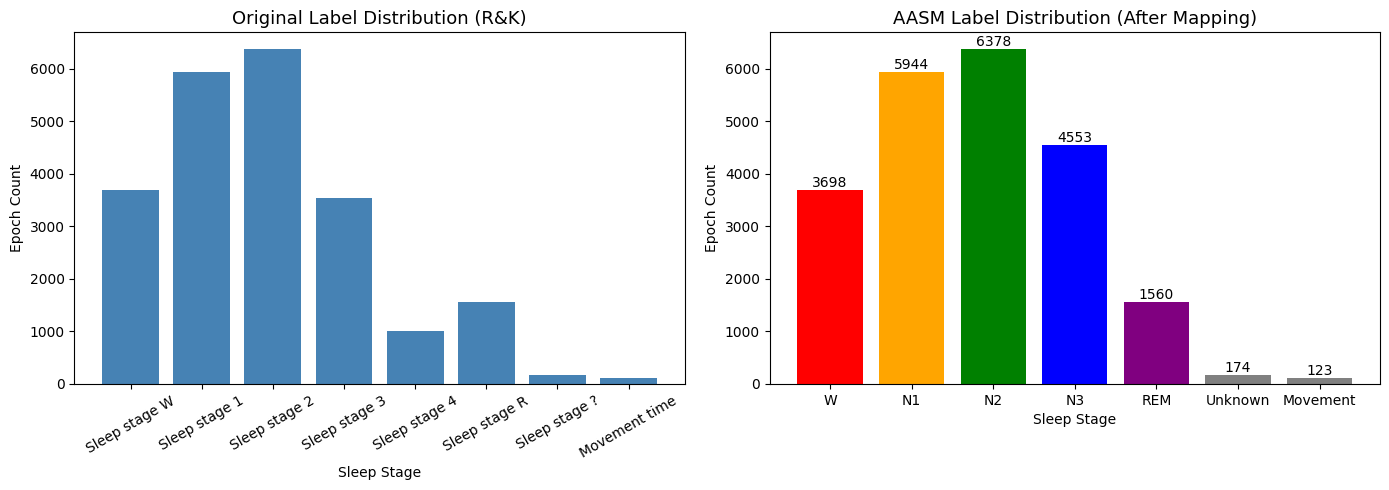

저장 완료: class_distribution.png


In [ ]:
psg_files = sorted([f for f in os.listdir(CASSETTE_PATH) if f.endswith("PSG.edf")])
hyp_files = sorted([f for f in os.listdir(CASSETTE_PATH) if f.endswith("Hypnogram.edf")])

all_labels = []
for hyp_file in hyp_files:
    ann = mne.read_annotations(os.path.join(CASSETTE_PATH, hyp_file))
    all_labels.extend(ann.description)


label_mapping = {
    'Sleep stage W': 'W',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',
    'Sleep stage R': 'REM',
    'Sleep stage ?': 'Unknown',
    'Movement time': 'Movement',
}
mapped_labels = [label_mapping.get(l, l) for l in all_labels]
label_counts = Counter(mapped_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

original_counts = Counter(all_labels)
axes[0].bar(original_counts.keys(), original_counts.values(), color='steelblue')
axes[0].set_title('Original Label Distribution (R&K)', fontsize=13)
axes[0].set_xlabel('Sleep Stage')
axes[0].set_ylabel('Epoch Count')
axes[0].tick_params(axis='x', rotation=30)

order = ['W', 'N1', 'N2', 'N3', 'REM', 'Unknown', 'Movement']
counts = [label_counts.get(l, 0) for l in order]
colors = ['red', 'orange', 'green', 'blue', 'purple', 'gray', 'gray']
axes[1].bar(order, counts, color=colors)
axes[1].set_title('AASM Label Distribution (After Mapping)', fontsize=13)
axes[1].set_xlabel('Sleep Stage')
axes[1].set_ylabel('Epoch Count')
for i, (label, count) in enumerate(zip(order, counts)):
    axes[1].text(i, count + 50, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: class_distribution.png")

/var/folders/d1/_m440hxx47ggls5y9hx3fg440000gn/T/ipykernel_83574/1577544807.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/var/folders/d1/_m440hxx47ggls5y9hx3fg440000gn/T/ipykernel_83574/1577544807.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/var/folders/d1/_m440hxx47ggls5y9hx3fg440000gn/T/ipykernel_83574/1577544807.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(
/var/folders/d1/_m440hxx47ggls5y9hx3fg440000gn/T/ipykernel_83574/1577544807.py:8: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations, verbose=False)


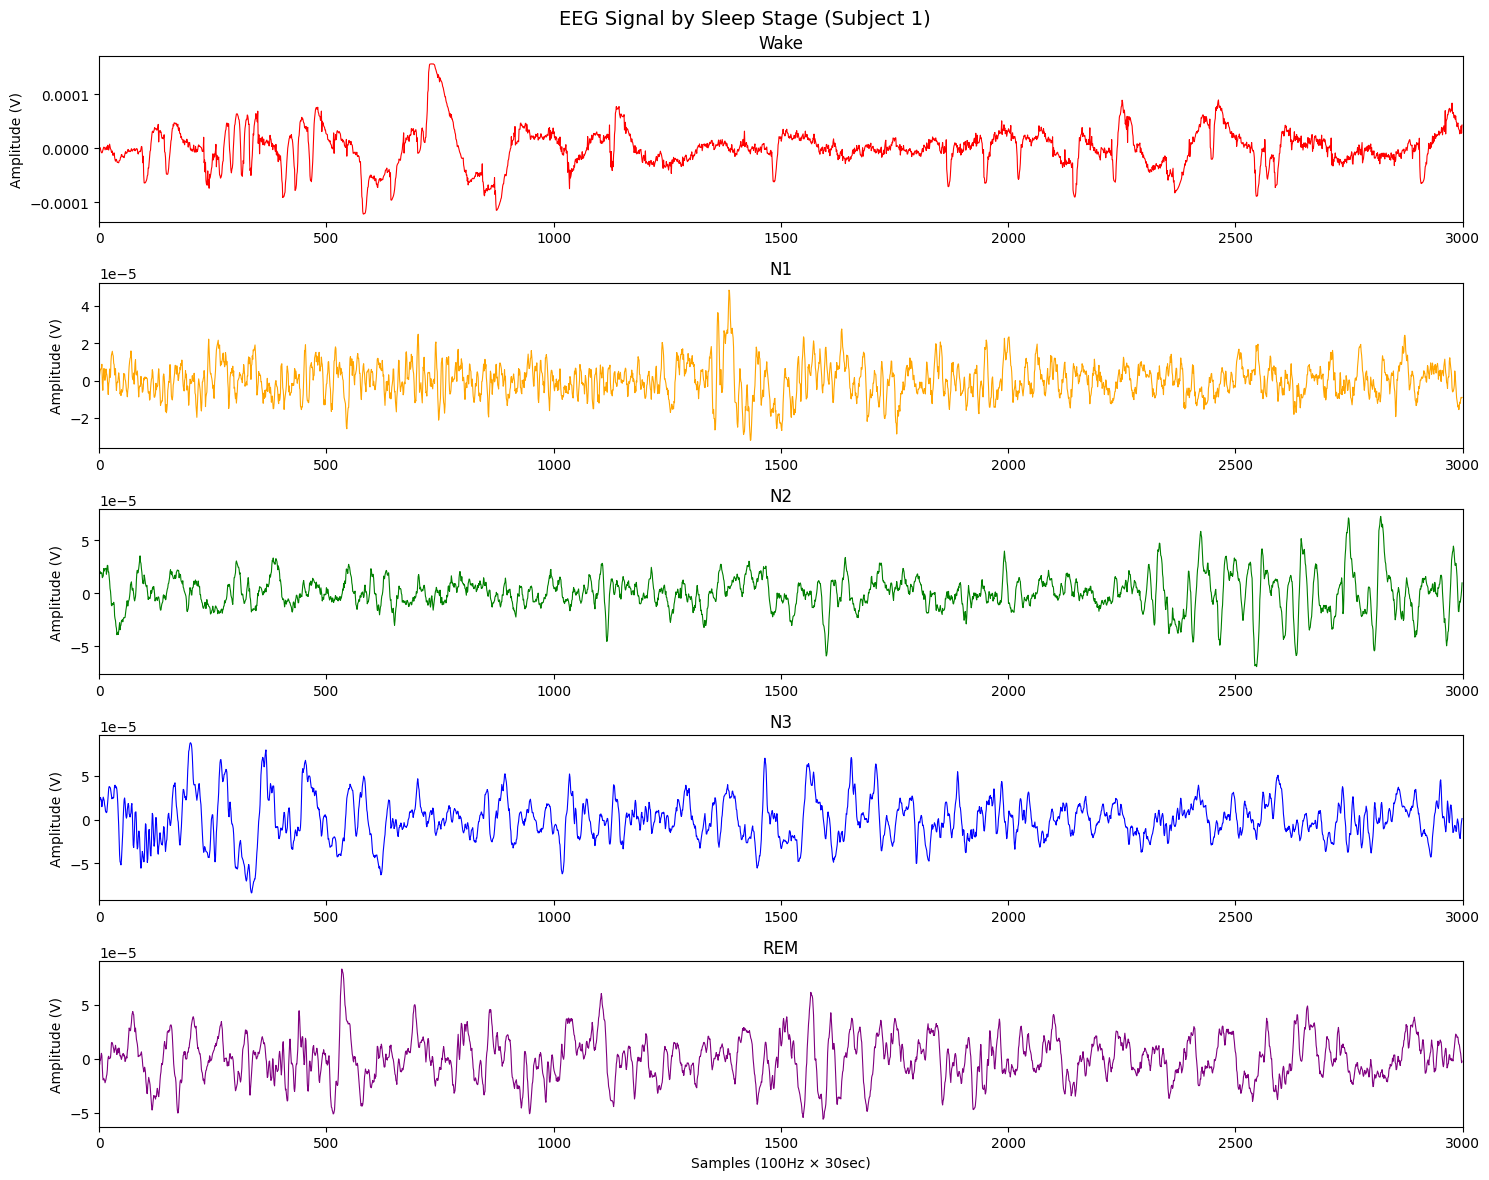

저장 완료: eeg_by_stage.png


In [4]:
raw = mne.io.read_raw_edf(
    os.path.join(CASSETTE_PATH, psg_files[0]),
    preload=True, verbose=False
)
raw.pick(['EEG Fpz-Cz', 'EEG Pz-Oz'])

annotations = mne.read_annotations(os.path.join(CASSETTE_PATH, hyp_files[0]))
raw.set_annotations(annotations, verbose=False)

stage_mapping = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,
    'Sleep stage R': 4,
}

events, event_id = mne.events_from_annotations(
    raw, event_id=stage_mapping, verbose=False
)
epochs = mne.Epochs(
    raw, events, event_id=event_id,
    tmin=0, tmax=29.99,
    baseline=None, verbose=False, preload=True
)

fig, axes = plt.subplots(5, 1, figsize=(15, 12))
stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
stage_keys  = [0, 1, 2, 3, 4]
colors = ['red', 'orange', 'green', 'blue', 'purple']

for i, (stage_name, stage_key, color) in enumerate(zip(stage_names, stage_keys, colors)):
    stage_data = epochs[stage_key].get_data()[:, 0, :]
    axes[i].plot(stage_data[0], color=color, linewidth=0.8)
    axes[i].set_title(f'{stage_name}', fontsize=12)
    axes[i].set_ylabel('Amplitude (V)')
    axes[i].set_xlim(0, 3000)

axes[-1].set_xlabel('Samples (100Hz × 30sec)')
plt.suptitle('EEG Signal by Sleep Stage (Subject 1)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'eeg_by_stage.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: eeg_by_stage.png")

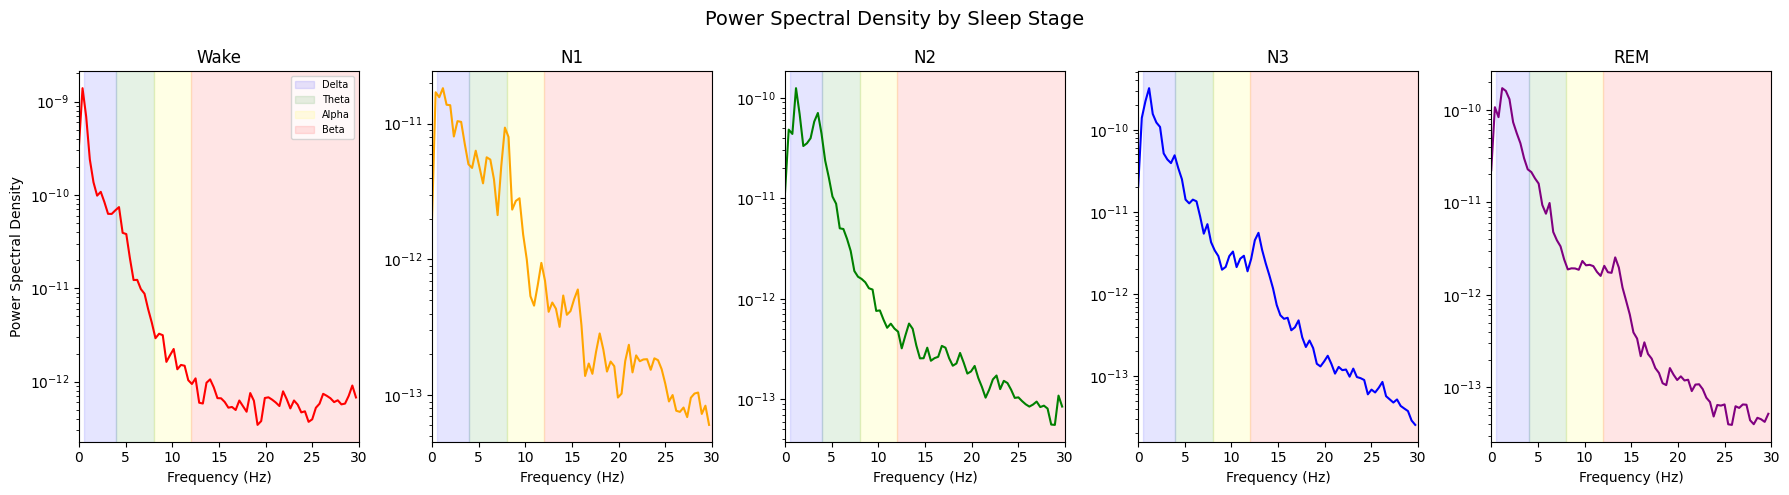

저장 완료: psd_by_stage.png


In [ ]:
from scipy import signal as scipy_signal

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
stage_keys  = [0, 1, 2, 3, 4]
colors = ['red', 'orange', 'green', 'blue', 'purple']

for i, (stage_name, stage_key, color) in enumerate(zip(stage_names, stage_keys, colors)):
    stage_data = epochs[stage_key].get_data()[:, 0, :]  # EEG Fpz-Cz
    
    freqs, psd = scipy_signal.welch(stage_data[0], fs=100, nperseg=256)
    
    mask = freqs <= 30
    axes[i].semilogy(freqs[mask], psd[mask], color=color)
    axes[i].set_title(f'{stage_name}', fontsize=12)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_xlim(0, 30)
    
    axes[i].axvspan(0.5, 4,   alpha=0.1, color='blue',   label='Delta')
    axes[i].axvspan(4,   8,   alpha=0.1, color='green',  label='Theta')
    axes[i].axvspan(8,   12,  alpha=0.1, color='yellow', label='Alpha')
    axes[i].axvspan(12,  30,  alpha=0.1, color='red',    label='Beta')

axes[0].set_ylabel('Power Spectral Density')
axes[0].legend(fontsize=7)
plt.suptitle('Power Spectral Density by Sleep Stage', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'psd_by_stage.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: psd_by_stage.png")

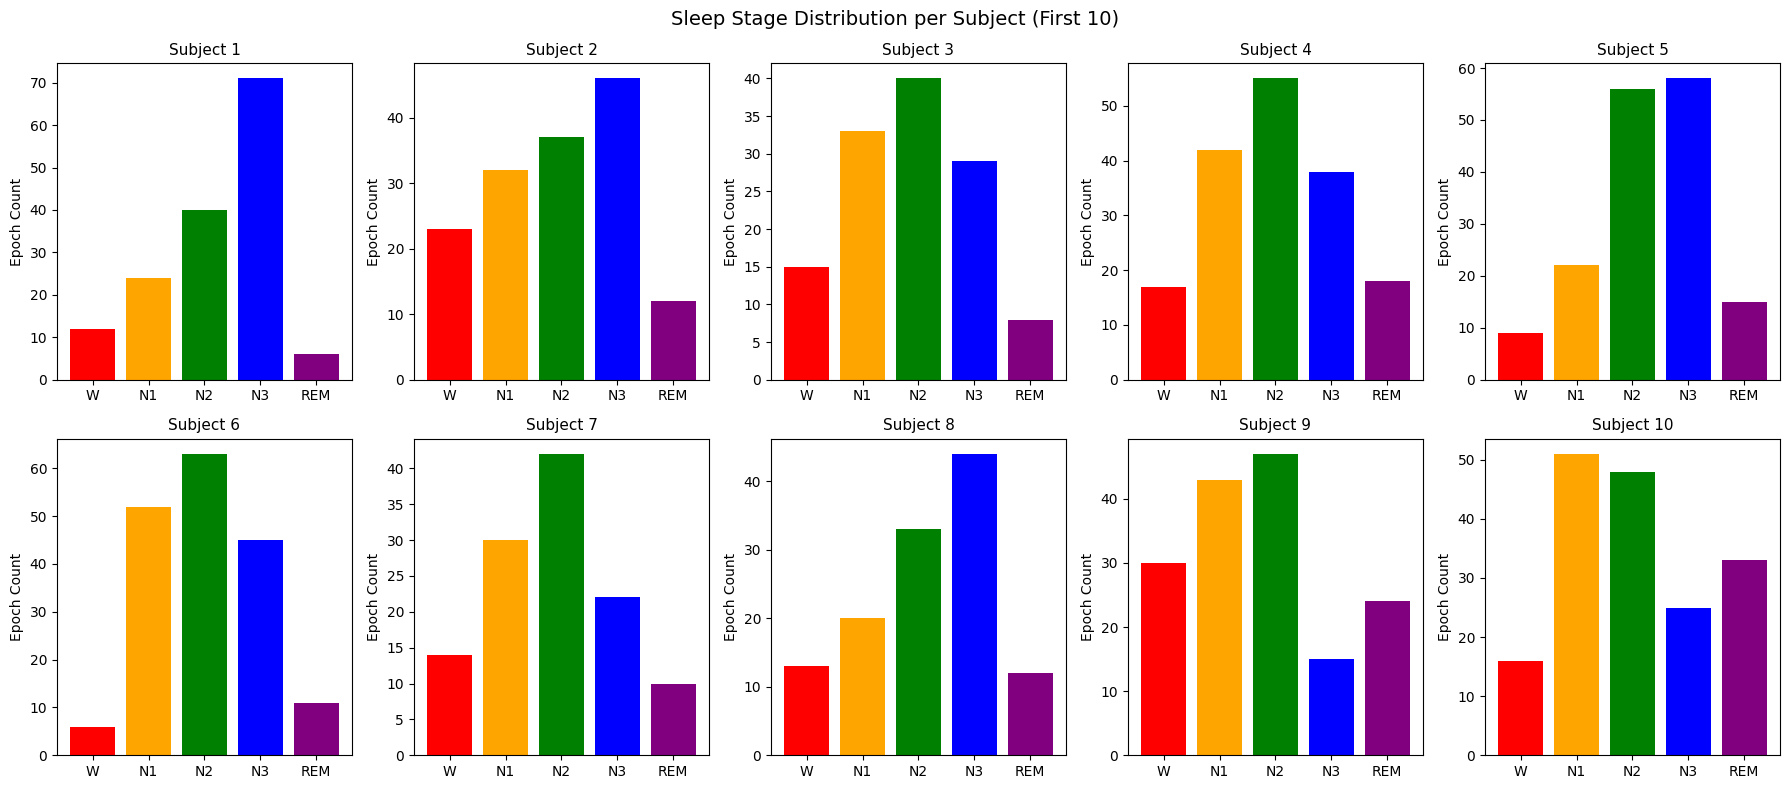

저장 완료: per_subject_distribution.png


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

label_mapping = {
    'Sleep stage W': 'W',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',
    'Sleep stage R': 'REM',
}
order = ['W', 'N1', 'N2', 'N3', 'REM']
colors = ['red', 'orange', 'green', 'blue', 'purple']

for idx in range(10):
    ann = mne.read_annotations(os.path.join(CASSETTE_PATH, hyp_files[idx]))
    mapped = [label_mapping.get(l, None) for l in ann.description]
    counts = Counter([l for l in mapped if l is not None])
    
    values = [counts.get(l, 0) for l in order]
    axes[idx].bar(order, values, color=colors)
    axes[idx].set_title(f'Subject {idx+1}', fontsize=11)
    axes[idx].set_ylabel('Epoch Count')

plt.suptitle('Sleep Stage Distribution per Subject (First 10)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'per_subject_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: per_subject_distribution.png")

In [ ]:
TELEMETRY_PATH = os.path.join(DATA_PATH, "sleep-telemetry")

psg_files_st = sorted([f for f in os.listdir(TELEMETRY_PATH) if f.endswith("PSG.edf")])
hyp_files_st = sorted([f for f in os.listdir(TELEMETRY_PATH) if f.endswith("Hypnogram.edf")])

print(f"PSG 파일 수: {len(psg_files_st)}")
print(f"Hypnogram 파일 수: {len(hyp_files_st)}")

all_labels_st = []
for hyp_file in hyp_files_st:
    ann = mne.read_annotations(os.path.join(TELEMETRY_PATH, hyp_file))
    all_labels_st.extend(ann.description)

label_mapping = {
    'Sleep stage W': 'W',
    'Sleep stage 1': 'N1',
    'Sleep stage 2': 'N2',
    'Sleep stage 3': 'N3',
    'Sleep stage 4': 'N3',
    'Sleep stage R': 'REM',
    'Sleep stage ?': 'Unknown',
    'Movement time': 'Movement',
}

mapped_labels_st = [label_mapping.get(l, l) for l in all_labels_st]
label_counts_st = Counter(mapped_labels_st)

print("\n[Sleep-Telemetry 레이블 분포]")
for label, count in sorted(label_counts_st.items()):
    print(f"{label}: {count}")

PSG 파일 수: 44
Hypnogram 파일 수: 44

[Sleep-Telemetry 레이블 분포]
Movement: 73
N1: 1348
N2: 1793
N3: 1729
REM: 393
W: 763


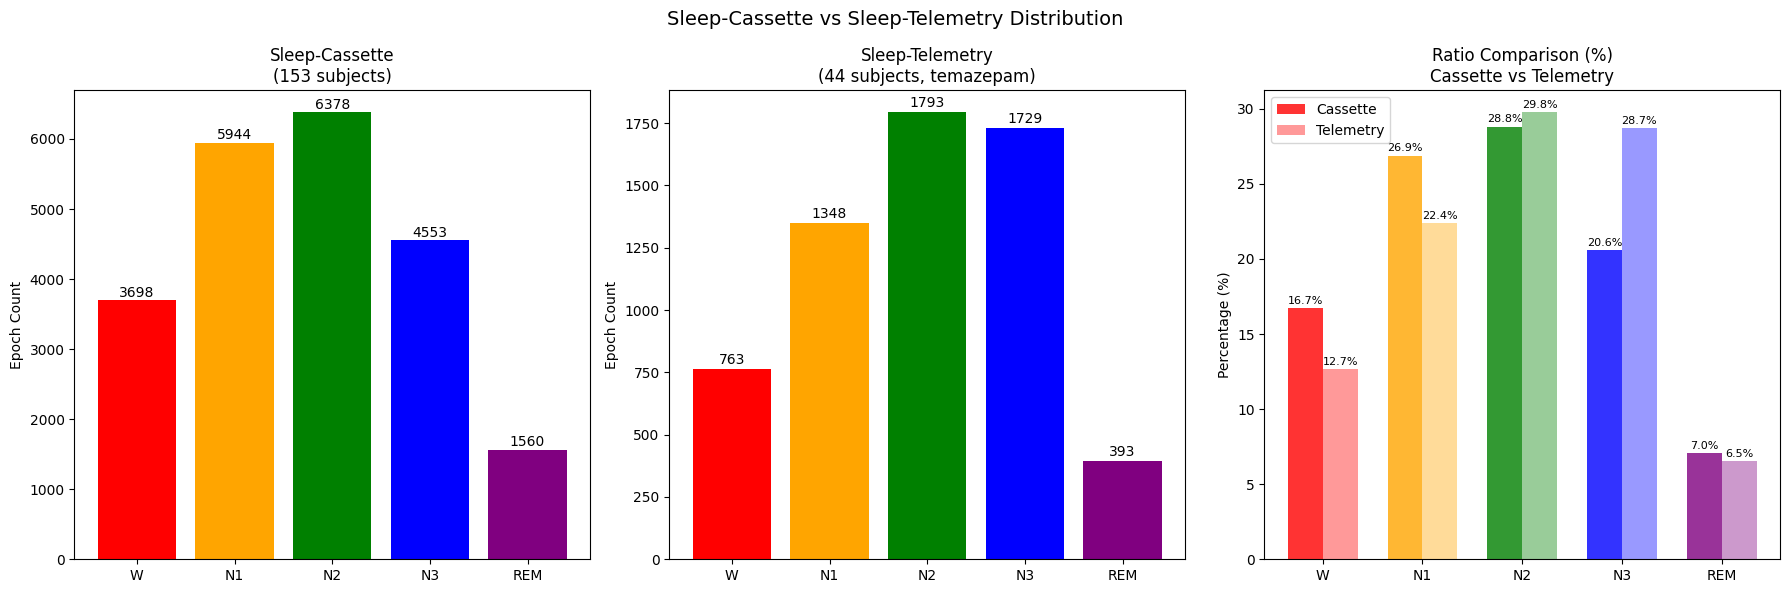

저장 완료: cassette_vs_telemetry.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

order = ['W', 'N1', 'N2', 'N3', 'REM']
colors = ['red', 'orange', 'green', 'blue', 'purple']

label_counts_sc = Counter(mapped_labels)
counts_sc = [label_counts_sc.get(l, 0) for l in order]
counts_st = [label_counts_st.get(l, 0) for l in order]

axes[0].bar(order, counts_sc, color=colors)
axes[0].set_title('Sleep-Cassette\n(153 subjects)', fontsize=12)
axes[0].set_ylabel('Epoch Count')
for i, count in enumerate(counts_sc):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=10)

axes[1].bar(order, counts_st, color=colors)
axes[1].set_title('Sleep-Telemetry\n(44 subjects, temazepam)', fontsize=12)
axes[1].set_ylabel('Epoch Count')
for i, count in enumerate(counts_st):
    axes[1].text(i, count + 20, str(count), ha='center', fontsize=10)

total_sc = sum(counts_sc)
total_st = sum(counts_st)
ratio_sc = [c/total_sc*100 for c in counts_sc]
ratio_st = [c/total_st*100 for c in counts_st]

x = np.arange(len(order))
width = 0.35
axes[2].bar(x - width/2, ratio_sc, width, color=colors, alpha=0.8, label='Cassette')
axes[2].bar(x + width/2, ratio_st, width, color=colors, alpha=0.4, label='Telemetry')
axes[2].set_title('Ratio Comparison (%)\nCassette vs Telemetry', fontsize=12)
axes[2].set_ylabel('Percentage (%)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(order)
axes[2].legend()
for i, (r1, r2) in enumerate(zip(ratio_sc, ratio_st)):
    axes[2].text(i - width/2, r1 + 0.3, f'{r1:.1f}%', ha='center', fontsize=8)
    axes[2].text(i + width/2, r2 + 0.3, f'{r2:.1f}%', ha='center', fontsize=8)

plt.suptitle('Sleep-Cassette vs Sleep-Telemetry Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'cassette_vs_telemetry.png'), dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: cassette_vs_telemetry.png")